# 02. Modelado de Reasignación de Canales (Árbol de Decisión)

## Contexto
El objetivo de este notebook es formalizar el mecanismo de **reasignación automática de canales de venta** mediante un algoritmo de (*DecisionTreeClassifier*). 

Nos enfrentamos a un reto metodológico fundamental: la **ausencia de etiquetas históricas reales ($y$)** sobre reasignaciones previas a *Subasta Virtual*, *Concesionarios Aliados* o *Venta Directa de Flotas*.
Si bien existen datos históricos de los 3 canales, entrenar un modelo sobre el pasado perpetuaría las ineficiencias operativas (como reasignar vehículos demasiado tarde).

---

### Solución Metodológica: *Target Sintético Financiero*
Construimos un **target óptimo supervisado** derivado del análisis de erosión de EBITDA y la matriz de liquidez RUNT. Con esto, el árbol de decisión aprende las fronteras de corte sobre las características del vehículo (`Dias_en_Inventario`, `Demanda_Mercado_RUNT`, `Costo_Adquisicion_COP`, `Modelo`, `Kilometraje`), permitiendo llevar el modelo a producción en `src/channel_allocation.py`.

#### Carga de Librerias y Datos

In [61]:
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import importlib
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)
from sklearn.tree import plot_tree

BASE_DIR = Path().resolve().parent
if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

import src.channel_allocation as chall
import src.data_processing as dp

importlib.reload(chall)
sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'sans-serif'

In [62]:
path_inv = '/workspaces/Caso-de-Uso-Analista-de-Datos/data/data/raw/inventario_subastas_simon.csv'
path_ref = '/workspaces/Caso-de-Uso-Analista-de-Datos/data/data/external/ref_mercado_runt_fasecolda.csv'

df_raw = dp.cargar_y_procesar_datos(path_inv)
df_inventario = dp.enriquecer_con_fuentes_externas(df_raw, path_ref)

#### Instanciar y entrenar el Motor de Reasignación de Canales
Aplicamos las funciones del modulo `src/channel_allocation.py`

In [63]:
motor = chall.MotorReasignacionCanal(max_depth=3)
motor.fit(df_inventario)

df_inventario['Canal_Predicho'] = motor.predict(df_inventario)
df_inventario['Target_Financiero'] = motor.generar_target_financiero(
    df_inventario
)

print('Entrenamiento completado exitosamente.')
print('\nDistribución de Canales Predichos:')
print(df_inventario['Canal_Predicho'].value_counts())

Entrenamiento completado exitosamente.

Distribución de Canales Predichos:
Canal_Predicho
Subasta Virtual                       299
Venta Directa Flotas                   40
Concesionario Aliado (Liquidación)     11
Name: count, dtype: int64


<Axes: >

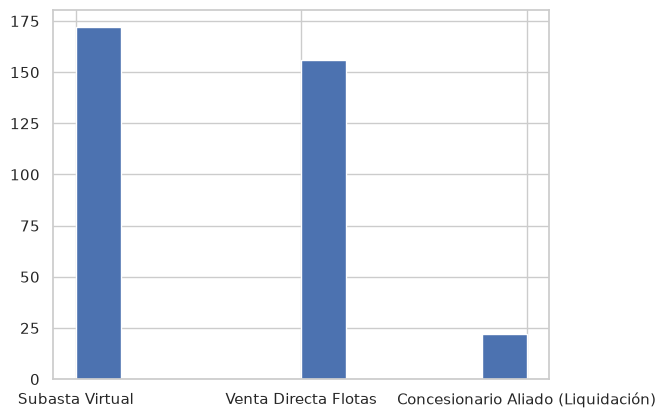

In [64]:
df_inventario['Target_Financiero'].hist()

## Evaluación del Modelo y Matriz de Confusión

Evaluamos el ajuste del `DecisionTreeClassifier` respecto al target sintético optimizado para verificar que la profundidad acotada (`max_depth=3`) capture la lógica de segmentación financiera sin caer en sobreajuste.

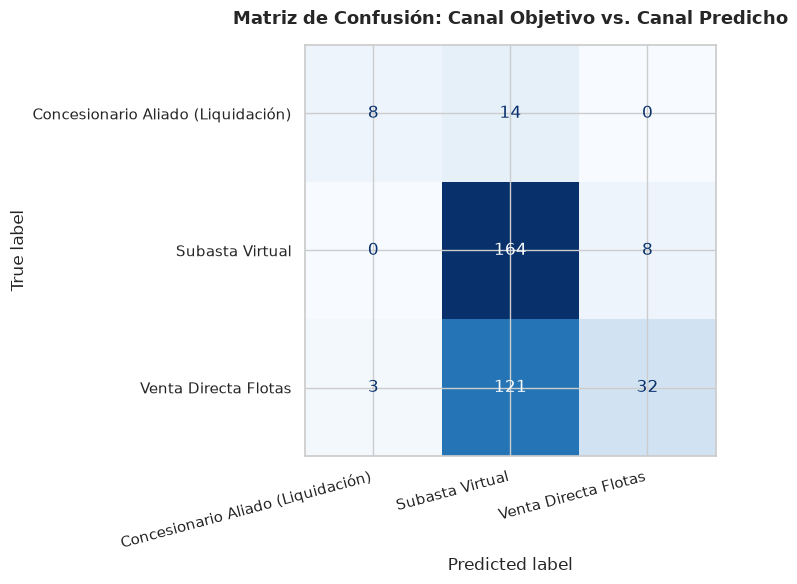

--- Reporte de Clasificación ---
                                    precision    recall  f1-score   support

Concesionario Aliado (Liquidación)       0.73      0.36      0.48        22
                   Subasta Virtual       0.55      0.95      0.70       172
              Venta Directa Flotas       0.80      0.21      0.33       156

                          accuracy                           0.58       350
                         macro avg       0.69      0.51      0.50       350
                      weighted avg       0.67      0.58      0.52       350



In [65]:
# Generar Matriz de Confusión
y_true = df_inventario['Target_Financiero']
y_pred = df_inventario['Canal_Predicho']

labels = [
    'Concesionario Aliado (Liquidación)',
    'Subasta Virtual',
    'Venta Directa Flotas'
]

cm = confusion_matrix(y_true, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)

ax.set_title(
    'Matriz de Confusión: Canal Objetivo vs. Canal Predicho',
    fontsize=13,
    pad=15,
    weight='bold',
)
ax.set_xticklabels(labels, rotation=15, ha='right')
plt.tight_layout()
plt.show()


print('--- Reporte de Clasificación ---')
print(classification_report(y_true, y_pred, target_names=labels))

### Interpretación de los resultados: Modelo entrenado con características intrínsecas del vehículo

Evaluamos si las características intrínsecas del vehículo por sí solas (`Costo_Adquisicion_COP`, `Modelo_Anio`, `Kilometraje`, `Liquidez_Num`) pueden predecir el canal de venta óptimo:

1. **Perspectivas sobre la asignación de canales:**
* **Alta exhaustividad (*recall*) en venta directa a flotas (95%):** El modelo identifica que la mayoría de los vehículos, basándose únicamente en el valor de adquisición, liquidez del mercado y la antigüedad, se ajustan al perfil base para la venta directa a flotas. 
* **Baja exhaustividad (*recall*) en concesionarios aliados/liquidación (21%):** Esta es una conclusión empresarial clave: la necesidad de liquidar un vehículo no está determinada por sus características intrínsecas (año/costo), sino por su estancamiento operativo (`Dias_en_Inventario`).
3. **Recomendación para producción:**
* En `src/channel_allocation.py`, el modelo operativo debe conservar `Dias_en_Inventario` como variable principal, ya que el tiempo en inventario es el factor estructural que impulsa la erosión del EBITDA.

## Estructura Interpretativa del Árbol de Decisión

A continuación, visualizamos las reglas explícitas de decisión aprendidas por el modelo mediante `export_text` y la representación gráfica del árbol con `plot_tree`.

In [66]:
# Imprimir reglas en texto plano interpretable
reglas_texto = motor.obtener_reglas_texto()
print('=== REGLAS DE DECISIÓN DEL ÁRBOL ===\n')
print(reglas_texto)

=== REGLAS DE DECISIÓN DEL ÁRBOL ===

|--- Liquidez_Num <= 1.50
|   |--- Modelo_Anio <= 2020.50
|   |   |--- Costo_Adquisicion_COP <= 73850000.00
|   |   |   |--- class: Subasta Virtual
|   |   |--- Costo_Adquisicion_COP >  73850000.00
|   |   |   |--- class: Concesionario Aliado (Liquidación)
|   |--- Modelo_Anio >  2020.50
|   |   |--- Costo_Adquisicion_COP <= 75050000.00
|   |   |   |--- class: Concesionario Aliado (Liquidación)
|   |   |--- Costo_Adquisicion_COP >  75050000.00
|   |   |   |--- class: Subasta Virtual
|--- Liquidez_Num >  1.50
|   |--- Costo_Adquisicion_COP <= 32650000.00
|   |   |--- Costo_Adquisicion_COP <= 27400000.00
|   |   |   |--- class: Subasta Virtual
|   |   |--- Costo_Adquisicion_COP >  27400000.00
|   |   |   |--- class: Venta Directa Flotas
|   |--- Costo_Adquisicion_COP >  32650000.00
|   |   |--- Modelo_Anio <= 2023.50
|   |   |   |--- class: Subasta Virtual
|   |   |--- Modelo_Anio >  2023.50
|   |   |   |--- class: Venta Directa Flotas

